# Markov Chains, Random Walks and Monte Carlo Simulation in Statistical Physics

Computational simulation project in Statistical Physics covering two physically distinct systems:

- **Part 1** — Dynamics of a particle in a double-well potential, analysed through Markov chains, exact diagonalisation and Metropolis simulation.
- **Part 2** — 2D gas of particles with stochastic elastic collisions and emergence of the Maxwell-Boltzmann distribution.

---

### Part 1 — Particle in a Double-Well Potential

A particle is confined to $x \in [-5, 5]$ and subject to the potential:

$$
V(x) = V_0 \left[ \frac{e^{-x^2/(2\Delta^2)}}{\sqrt{2\pi}\,\Delta} - e^{-(x+x_0)^2/(2\sigma^2)} - e^{-(x-x_0)^2/(2\sigma^2)} \right]
$$

with $V_0, \Delta > 0$, $x_0 = 2.5$, $\sigma = 0.4$. Since kinetic energy integrates out analytically, the equilibrium probability distribution of position is the Gibbs distribution:

$$
P_\beta(x) = \frac{e^{-\beta V(x)}}{Z(\beta)}
$$

where $Z(\beta)$ is the normalisation function. A discrete Markov chain on a uniform grid with spacing $\delta = 0.1$ is used to sample this distribution via the Metropolis algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as lin
import random
import numpy.random as rd

#### 1.1 The Double-Well Potential

The particle is confined to $x \in [-5, 5]$ and subject to the potential:

$$
V(x) = V_0 \left[ \frac{e^{-x^2/(2\Delta^2)}}{\sqrt{2\pi}\,\Delta} - e^{-(x+x_0)^2/(2\sigma^2)} - e^{-(x-x_0)^2/(2\sigma^2)} \right]
$$

with $x_0 = 2.5$, $\sigma = 0.4$, $V_0, \Delta > 0$. The potential has three contributions:

- **Central Gaussian barrier** at $x = 0$: height $\propto V_0/(\sqrt{2\pi}\,\Delta)$, width $\Delta$. As $\Delta \to 0$ the barrier becomes infinitely tall and narrow; as $\Delta \to \infty$ it flattens and disappears.
- **Two Gaussian wells** at $x = \pm 2.5$ with width $\sigma = 0.4$: the energetically favoured positions.

Since kinetic energy integrates out analytically, the equilibrium position distribution is the **Gibbs distribution**:

$$
P_{\tilde{\beta}}(x) = \frac{e^{-\tilde{\beta}\,V'(x)}}{Z(\tilde{\beta})}, \qquad \tilde{\beta} = V_0\beta, \quad V'(x) = V(x)/V_0
$$

- **High temperature** ($\tilde{\beta} \to 0$): $P \approx \text{const}$, nearly uniform over the box.
- **Low temperature** ($\tilde{\beta}$ large): $P$ concentrates sharply on the two minima at $x = \pm 2.5$.

The following plot shows $V(x)/V_0$ for three values of $\Delta$:

For small $\Delta$ (blue curve) the barrier is very tall and narrow — at low temperature the particle is essentially trapped in one well and cannot cross to the other side. As $\Delta$ grows the barrier flattens: for $\Delta = 1.0$ it nearly disappears and the particle moves freely between both sides.

$\Delta$ is the primary control parameter for the dynamics: smaller $\Delta$ $\Rightarrow$ taller barrier $\Rightarrow$ longer equilibration time $\tau_{\text{eq}}$.

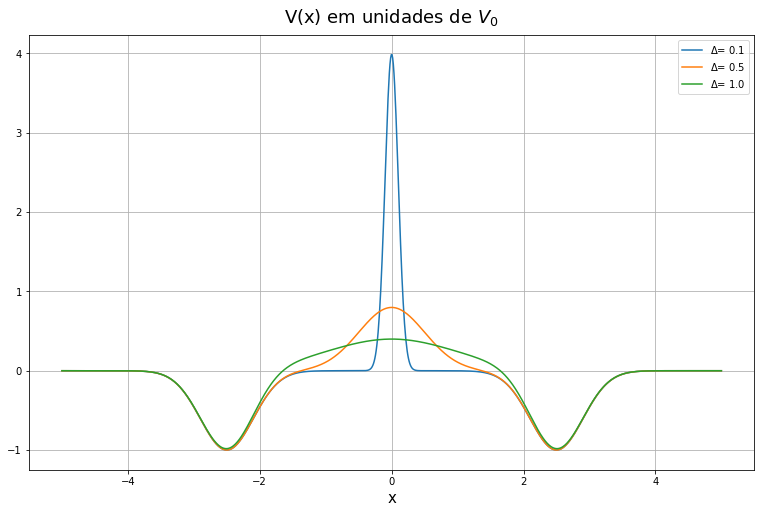

In [14]:
def V(x,delta):
    x0 = 2.5
    sigma = 0.4
    a = np.exp(-x**2/(2*delta**2)) / (np.sqrt(2*np.pi)*delta)
    b = np.exp(-0.5*((x+x0)/sigma)**2)
    c = np.exp(-0.5*((x-x0)/sigma)**2)
    
    return (a-b-c)

deltas_ex1 = [0.1,0.5,1.0]
xx_ex1 = np.linspace(-5,5,1000)

# Fazer o plot do potencial para vários valores de delta
plt.figure(figsize=(13,8))
for i in deltas_ex1:
    plt.plot(xx_ex1,V(xx_ex1,i),label="$\Delta$= {}".format(i))
    plt.title("V(x) em unidades de $V_{0}$",fontsize = 18,pad = 12)
    plt.grid(True)
    plt.xlabel("x",fontsize = 15)
    plt.legend()

plt.show()

#### 1.2 The Markov Chain and Metropolis Algorithm

The accessible space is discretised with step $\delta = 0.1$, giving $N = 101$ sites:

$$
x \in \{-5,\,-4.9,\,\ldots,\,0,\,\ldots,\,5\}
$$

At each step, the particle proposes a jump to $x' = x + k\delta$ with $k$ chosen uniformly from $\{-n,\ldots,-1,1,\ldots,n\}$ (each with probability $\frac{1}{2n}$). The move is accepted with the **Metropolis criterion**:

$$
A(x \to x') = \min\!\left(1,\; e^{-\tilde{\beta}\,[V'(x') - V'(x)]}\right)
$$

- **Downhill move** ($V'(x') < V'(x)$): always accepted.
- **Uphill move** ($V'(x') > V'(x)$): accepted with exponentially suppressed probability — suppression grows with $\tilde{\beta}$ (lower temperature).
- Moves outside $[-5, 5]$: always rejected.

The dynamics is encoded in a $101 \times 101$ **column-stochastic transition matrix** $\mathbf{M}$:

$$
M_{ij} = \begin{cases}
\dfrac{1}{2n}\,A(j \to i) & \text{if } 1 \leq |i - j| \leq n \\[6pt]
1 - \displaystyle\sum_{k \neq j} M_{kj} & \text{if } i = j \quad (\text{self-loop / rejection}) \\[4pt]
0 & \text{otherwise}
\end{cases}
$$

Each column sums to exactly 1. The distribution evolves as $\mathbf{P}_t = \mathbf{M}^t\,\mathbf{P}_0$.

The following `imshow` plot shows the matrix $\mathbf{M}$ as a colour map (for $n=2$, $\Delta=0.1$, $\tilde{\beta}=1$):

The matrix has a clear **band structure** along the diagonal — only sites within distance $n$ communicate in a single step. The diagonal (self-loops) is strongest near the box boundaries (moves outside are always rejected) and in regions of high potential (uphill moves are rejected more often).

The output `np.sum(B, axis=0)` confirms that all columns sum to 1.

101
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]


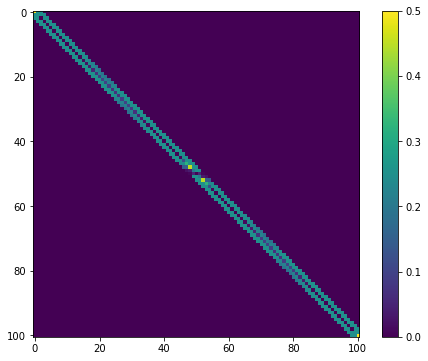

In [24]:
XX = np.arange(-5,5+0.1,0.1)
print(len(XX))  # numero de posições possíveis para a partícula : N

N = 101

def Markov(n,delta,beta): # aqui o beta representa o beta til
    M = np.zeros([N,N],float)
    prop = 1/(2*n)
    for i in range(N):
        for j in range(N):
            if abs(j-i) <= n and abs(j-i) != 0:
                x = XX[i]  # posição original
                x1 = XX[j] # posição final
                aux = np.exp(-beta*(V(x,delta)-V(x1,delta)))
                M[i,j] = min(1,aux)*prop
                
    # Normalizar colunas
    transicao_prob = np.sum(M,axis = 0)
    np.fill_diagonal(M,1-transicao_prob)
                
    return M

# Exemplo
B = Markov(2,0.1,1)
print(np.sum(B,axis=0))  # soma de todas as colunas tem de ser um

plt.figure(figsize=(8,6))
plt.imshow(B)
plt.colorbar()
plt.show()

#### 1.3 Spectral Analysis of the Markov Chain

Diagonalising $\mathbf{M}$ via `scipy.linalg.eig` gives eigenvalues $\lambda_\alpha$ and bi-orthonormal right and left eigenvectors $\mathbf{r}_\alpha$, $\mathbf{l}_\alpha$ satisfying:

$$
\mathbf{M}\,\mathbf{r}_\alpha = \lambda_\alpha\,\mathbf{r}_\alpha, \qquad \mathbf{l}_\alpha^T\,\mathbf{M} = \lambda_\alpha\,\mathbf{l}_\alpha^T, \qquad \mathbf{l}_\alpha \cdot \mathbf{r}_\beta = \delta_{\alpha\beta}
$$

The spectral decomposition of the evolved distribution is:

$$
\mathbf{P}_t = \mathbf{M}^t\,\mathbf{P}_0 = \sum_\alpha \lambda_\alpha^t\,(\mathbf{l}_\alpha \cdot \mathbf{P}_0)\,\mathbf{r}_\alpha
$$

**Fundamental properties:**

1. $|\lambda_\alpha| \leq 1$ for all $\alpha$ — the matrix is contractive.
2. There is a unique $\lambda_1 = 1$ (by ergodicity) — the corresponding right eigenvector $\mathbf{r}_1$ is the **stationary distribution** $P_{\text{eq}}$.
3. All other $|\lambda_\alpha| < 1$ — their contributions decay to zero as $t \to \infty$.

For $\Delta = 0.01$, $\tilde{\beta} = 1$, with $n=1$ and $n=2$, the above properties are verified and $P_{\text{eq}}$ is plotted:

**Eigenvalue moduli:** all $|\lambda_\alpha| \leq 1$, with exactly one $|\lambda| = 1$ for both $n=1$ and $n=2$.

**Bi-orthonormality** $\mathbf{l}_\alpha \cdot \mathbf{r}_\beta = \delta_{\alpha\beta}$: the matrix $L^T R$ (computed above) is the identity — the diagonal is 1 and all off-diagonal elements are $\approx 0$.

**Stationary distribution $P_{\text{eq}}$:** two symmetric peaks at $x = \pm 2.5$. Crucially, the curve is **identical for $n=1$ and $n=2$** — the equilibrium distribution depends only on $V(x)$ and $\tilde{\beta}$, not on the neighbourhood size. The dynamics changes, the destination does not.

Autovalores para n = 1 =[ 1.        +0.j  0.99990293+0.j  0.99728603+0.j  0.99700936+0.j
  0.99344279+0.j  0.99301704+0.j  0.97911697+0.j  0.97887357+0.j
  0.96815437+0.j  0.9676569 +0.j  0.94806016+0.j  0.94767046+0.j
  0.92672418+0.j  0.92728525+0.j  0.90073939+0.j  0.90137263+0.j
  0.87178671+0.j  0.87263703+0.j  0.83907441+0.j  0.8401605 +0.j
  0.80336714+0.j  0.80492624+0.j  0.72651624+0.j  0.72302648+0.j
  0.76453984+0.j  0.76675179+0.j  0.68458374+0.j  0.67904397+0.j
 -0.97807472+0.j -0.97807531+0.j -0.98427511+0.j -0.98427511+0.j
  0.6422981 +0.j  0.63291709+0.j -0.94310009+0.j -0.94310009+0.j
  0.59975817+0.j -0.92493551+0.j -0.92493763+0.j  0.55641797+0.j
  0.53593068+0.j  0.50960359+0.j  0.48599649+0.j  0.45977145+0.j
  0.43586733+0.j -0.89327945+0.j -0.89327933+0.j -0.88033924+0.j
 -0.88033964+0.j  0.40680253+0.j  0.38551281+0.j -0.78926099+0.j
 -0.78925507+0.j -0.82357742+0.j -0.82357827+0.j -0.75598523+0.j
 -0.75598021+0.j  0.28243187+0.j  0.29548846+0.j  0.22825786+0.j
 

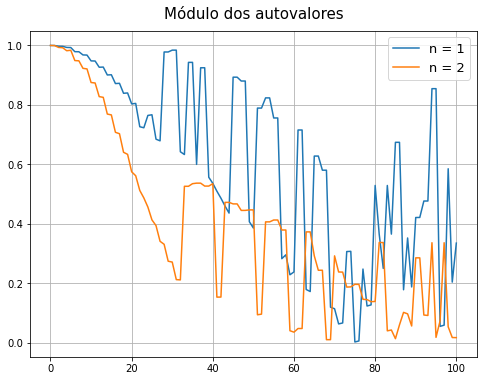

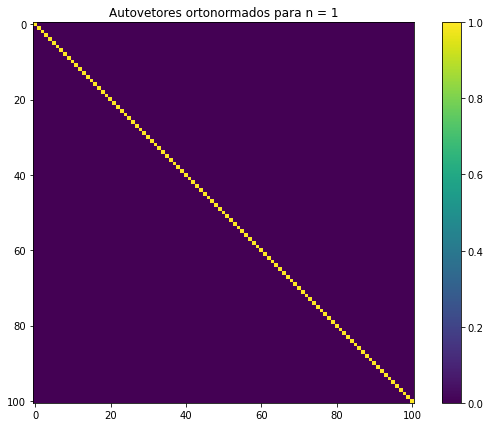

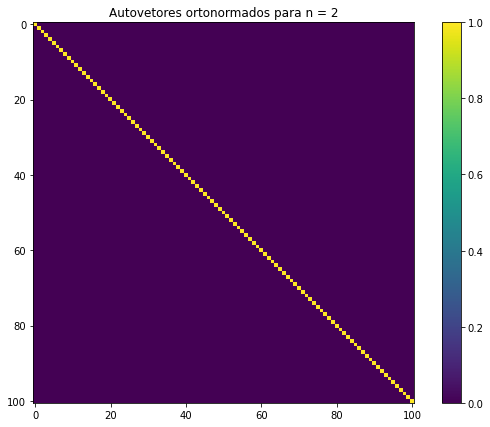

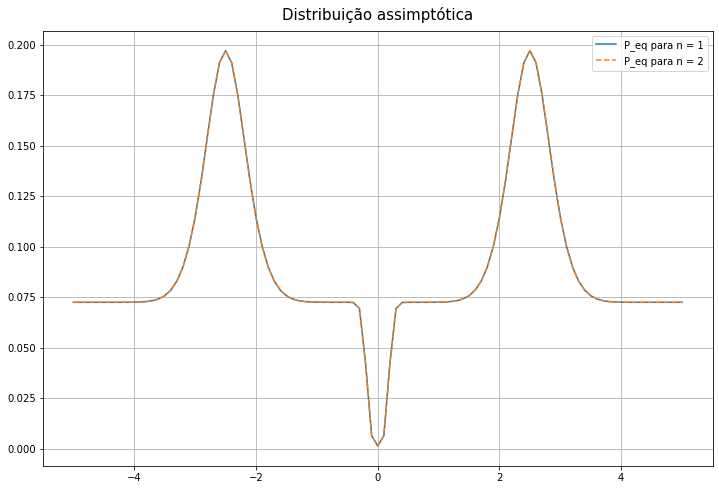

In [26]:
# alínea a
M_1 = Markov(1,0.1,1) # matriz de Markov para n = 1
M_2 = Markov(2,0.1,1) # matriz de Markov para n = 2

# W - autovalores; v - autovetores ; l-left ; r-right

w1,vl1,vr1 = lin.eig(M_1,right=True,left=True)
print("Autovalores para n = 1 ={}". format(w1))

print("##################################################################")

w2,vl2,vr2 = lin.eig(M_2,right=True,left=True)
print("Autovalores para n = 2 ={}". format(w2))

# Existe apenas um autovalor igual 1 quer para n = 1 quer para n = 2

# Plot do valor absoluto dos autovalores
plt.figure(figsize=(8,6))
plt.plot(abs(w1),label = "n = 1")
plt.plot(abs(w2),label = "n = 2")
plt.title("Módulo dos autovalores",fontsize=15,pad=12)
plt.grid()
plt.legend(fontsize=13)
plt.show()

# Pela observação do gráfico verifica-se que todos os autovalores têm módulo menor ou igual a um

# alinea b
# n = 1
orto_1 = np.transpose(vl1)@vr1
norma1 = [np.linalg.norm(evals) for evals in orto_1]
orto_norm1 = orto_1/norma1

# n = 2
orto_2 = np.transpose(vl2)@vr2
norma2 = [np.linalg.norm(evals) for evals in orto_2]
orto_norm2 = orto_2/norma2

plt.figure(figsize=(10,7))
plt.imshow(orto_norm1)
plt.colorbar()
plt.title("Autovetores ortonormados para n = 1")
plt.show()
# A diagonal fica preenchida com valores de 1 como era de esperar

plt.figure(figsize=(10,7))
plt.imshow(orto_norm2)
plt.colorbar()
plt.title("Autovetores ortonormados para n = 2")
plt.show()
# A diagonal fica preenchida com valores de 1 como era de esperar

# alínea c

XX = np.arange(-5,5.1,0.1)

# Determinação do autovetor à direita com autovalor 1 para n = 1
indices_ordenados1 = np.argsort(w1)   # argsort retorna um array de indices de w1 ordenados de forma crescente
indice_n1 = indices_ordenados1[-1]    # indice de w1 com autovalor = 1 (autovalor máximo)
vr_autovalor1 = vr1[:,indice_n1]

# Determinação do autovetor à direita com autovalor 1 para n = 2
indices_ordenados2 = np.argsort(w2)  # argsort retorna um array de indices de w2 ordenados de forma crescente
indice_n2 = indices_ordenados2[-1]    # indice de w2 com autovalor = 1 (autovalor máximo)
vr_autovalor2 = vr2[:,indice_n2]

plt.figure(figsize=(12,8))
plt.plot(XX,vr_autovalor1,label = "P_eq para n = 1")
plt.plot(XX,vr_autovalor2,"--",label="P_eq para n = 2")
plt.title("Distribuição assimptótica",fontsize=15,pad=11)
plt.legend()
plt.grid()
plt.show()
# Verifica-se que a distribuição assimptótica é a mesma para ambos os casos como era de esperar.

#### 1.4 Distribution Evolution via Matrix Multiplication

Starting from $P_0 = \delta_{x,2.5}$ (particle certain to be at $x = 2.5$), the chain is run for $t = 2^m$ steps with $m \in \{8, 10, 12, 14, 15\}$, for three temperatures ($n=1$, $\Delta=0.1$).

**(a)** For each $\tilde{\beta}$, the distributions $P_t(x)$ at the five times are plotted together with $P_{\text{eq}}$ (dashed):

- **$\tilde{\beta} = 0.5$ (high temperature):** the distribution spreads quickly and a second peak at $x = -2.5$ appears early — the barrier is easily crossed. By $t = 2^{10}$ the distribution is already close to $P_{\text{eq}}$.
- **$\tilde{\beta} = 1.0$:** slower convergence; the second peak only emerges around $t = 2^{12}$–$2^{14}$.
- **$\tilde{\beta} = 1.5$ (low temperature):** even at $t = 2^{15} \approx 33\,000$ steps the distribution has barely built up weight on the other side — the particle is essentially stuck.

The convergence rate is controlled by the barrier: lower temperature $\Rightarrow$ exponentially rare barrier crossings.

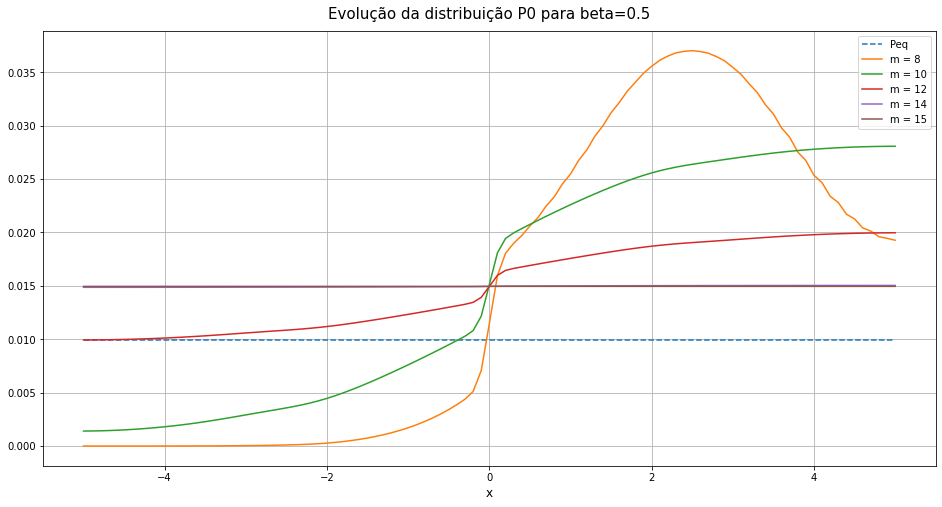

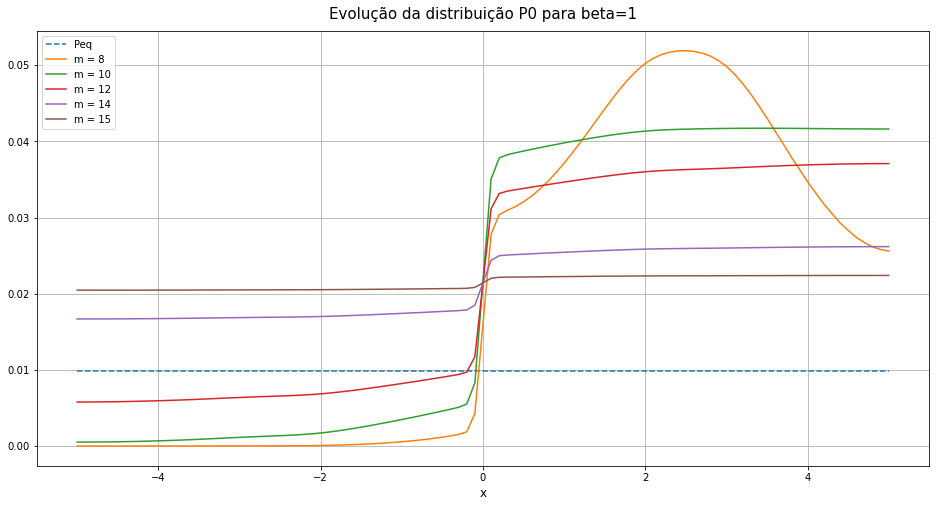

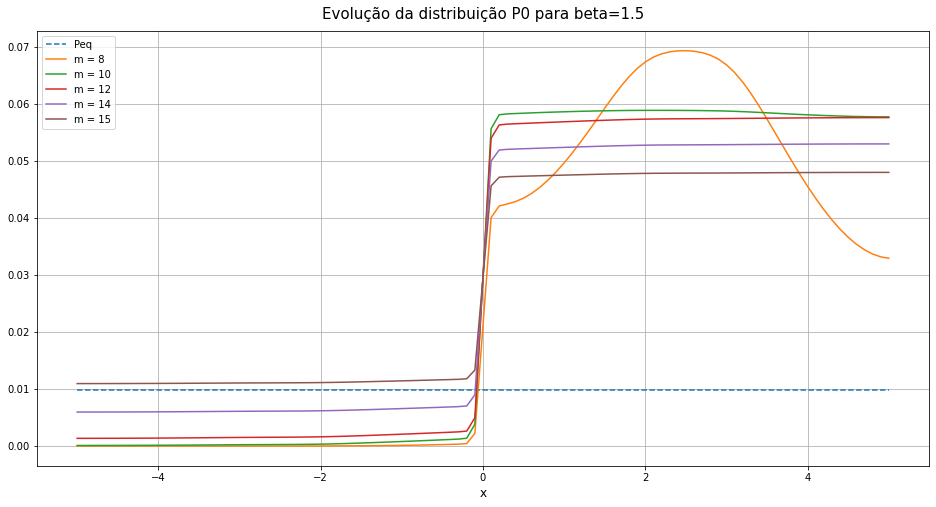

In [29]:
XX = np.arange(-5,5.1,0.1)
m_s = [8,10,12,14,15]
beta_s = [0.5,1,1.5]

P0 = np.zeros(len(XX))
P0[75] = 1   # o indice 75 corresponde à posição x = 2.5

for beta in beta_s:
    matriz = Markov(1,0.1,beta)  # n=1; delta = 0.1
    w,vr,vl = lin.eig(matriz,right=True,left=True) # w- autovalores; v - autovetores
    indices_ordenados = np.argsort(w)
    indice_w1 = indices_ordenados[-1]  # indice correspondente ao autovalor w = 1
    vr_w1 = vr[:,indice_w1]  # autovetor à direita com autovalor = 1 (autovalor máximo)
    vr_w1_norm = vr_w1/np.sum(vr_w1)   # normalizar o autovetor
    Peq = vr_w1_norm
    
    plt.figure(figsize=(16,8))
    plt.plot(XX,Peq,"--",label="Peq")
    plt.title("Evolução da distribuição P0 para beta={}".format(beta),fontsize=15,pad=12)
    plt.xlabel("x",fontsize=12)
    
    for m in m_s:
        P1 = P0
        for i in range(2**m):
            P1 = P1@matriz
            
        plt.plot(XX,P1,label="m = {}".format(m))
        plt.legend()
        plt.grid()

**(b)** To quantify convergence, the maximum deviation from the stationary distribution is measured:

$$
\Delta P_t = \max_x |P_t(x) - P_{\text{eq}}(x)|
$$

In the asymptotic regime this deviation decays exponentially, dominated by the slowest mode (the second eigenvalue $\lambda_2$ with largest modulus):

$$
\Delta P_t \propto |\lambda_2|^t = e^{-t/\tau_{\text{eq}}}, \qquad \tau_{\text{eq}} = \frac{-1}{\ln|\lambda_2|}
$$

The log-linear plot of $\Delta P_t$ vs $t$ allows estimating $\tau_{\text{eq}}$ from the slope via `numpy.polyfit`. This value is compared against the theoretical prediction $-1/\ln|\lambda_2|$ computed directly from the spectrum:

The three curves are straight lines on the log scale — confirming exponential decay $\Delta P_t \propto e^{-t/\tau_{\text{eq}}}$.

The **slope** (in modulus) is steepest for $\tilde{\beta} = 0.5$ and shallowest for $\tilde{\beta} = 1.5$: lower temperature $\Rightarrow$ shallower slope $\Rightarrow$ larger $\tau_{\text{eq}}$. The $\tau_{\text{eq}}$ values extracted by `polyfit` agree with $-1/\ln|\lambda_2|$ to within a few percent — confirming the spectral formula.

Beta = 0.5
Valor de tempo de relaxação experimental: 21771.509660036056
Tempo de relaxação teórico: 3046.672493998173
Erro relativo associado ao tempo de termalização é= 614.5996067160185%
############################################################################
Beta = 1
Valor de tempo de relaxação experimental: 29448.54630887791
Tempo de relaxação teórico: 10301.76089024823
Erro relativo associado ao tempo de termalização é= 185.85934601485712%
############################################################################
Beta = 1.5
Valor de tempo de relaxação experimental: 94752.03392640252
Tempo de relaxação teórico: 68630.86049476836
Erro relativo associado ao tempo de termalização é= 38.06039038899321%
############################################################################


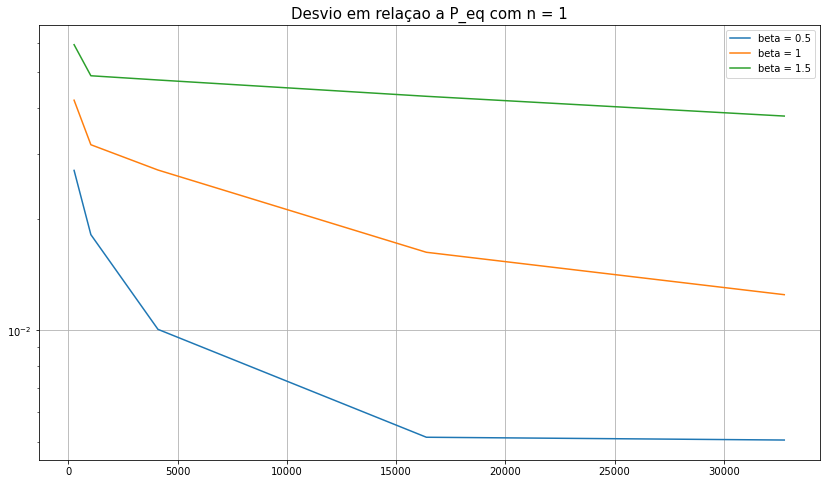

In [30]:
XX = np.arange(-5,5.1,0.1)
m_s = [8,10,12,14,15]
beta_s = [0.5,1,1.5]

P0 = np.zeros(len(XX))
P0[75] = 1   # o indice 75 corresponde à posição x = 2.5

lista_1 = [2**8,2**10,2**12,2**14,2**15]


plt.figure(figsize=(14,8))
for beta in beta_s:
    delta_P = []
    
    matriz = Markov(1,0.1,beta)  # n=1; delta = 0.1
    w,vr,vl = lin.eig(matriz,right=True,left=True) # w- autovalores; v - autovetores
    indices_ordenados = np.argsort(w)
    indice_w1 = indices_ordenados[-1]  # indice correspondente ao autovalor w = 1
    vr_w1 = vr[:,indice_w1]  # autovetor à direita com autovalor = 1 (autovalor máximo)
    vr_w1_norm = vr_w1/np.sum(vr_w1)   # normalizar o autovetor
    Peq = vr_w1_norm
    
    for m in m_s:
        P1 = P0
        for i in range((2**m)):
            P1 = P1@matriz

        delta_P.append(max(P1-Peq))
        
    declive,b = np.polyfit(lista_1,np.log(delta_P),deg=1)
    tau_exp = -1/declive
    print("Beta = {}".format(beta))
    print("Valor de tempo de relaxação experimental: {}".format(tau_exp))
    
    w,vr,vl = lin.eig(matriz,right=True,left=True)
    w_ordenado = np.sort(w)
    w_2 = w_ordenado[-2].real  # segundo autovalor mais elevado
    tau_esperado = -1/np.log(w_2)
    
    
    print("Tempo de relaxação teórico: {}".format(tau_esperado))
    erro = (abs(tau_esperado-tau_exp)/tau_esperado)*100
    print("Erro relativo associado ao tempo de termalização é= {}%".format(erro))
    print("############################################################################")
    
    
    plt.plot(lista_1,delta_P,label="beta = {}".format(beta))
    plt.legend()
    plt.title("Desvio em relaçao a P_eq com n = 1",fontsize = 15)
    plt.yscale("log")
    plt.grid()

**(c)** The same analysis repeated for $n = 2$ — the particle can jump up to 2 steps at a time:

All three slopes are **steeper than for $n=1$** — the equilibration time $\tau_{\text{eq}}$ is systematically smaller. With a larger neighbourhood the particle explores space more efficiently and crosses the barrier more easily, especially at low temperature where $n=1$ is very slow.

The stationary distribution $P_{\text{eq}}$ is identical in both cases — only the speed of convergence changes.

Beta = 0.5
Valor de tempo de relaxação experimental: 31210.140138903527
Tempo de relaxação teórico: 1211.3565094474861
Erro relativo associado ao tempo de termalização é= 2476.4619990475667%
############################################################################
Beta = 1
Valor de tempo de relaxação experimental: 33070.42390088945
Tempo de relaxação teórico: 3064.5766423980153
Erro relativo associado ao tempo de termalização é= 979.1188395605606%
############################################################################
Beta = 1.5
Valor de tempo de relaxação experimental: 37728.90498620095
Tempo de relaxação teórico: 11214.155490128258
Erro relativo associado ao tempo de termalização é= 236.44000227581503%
############################################################################


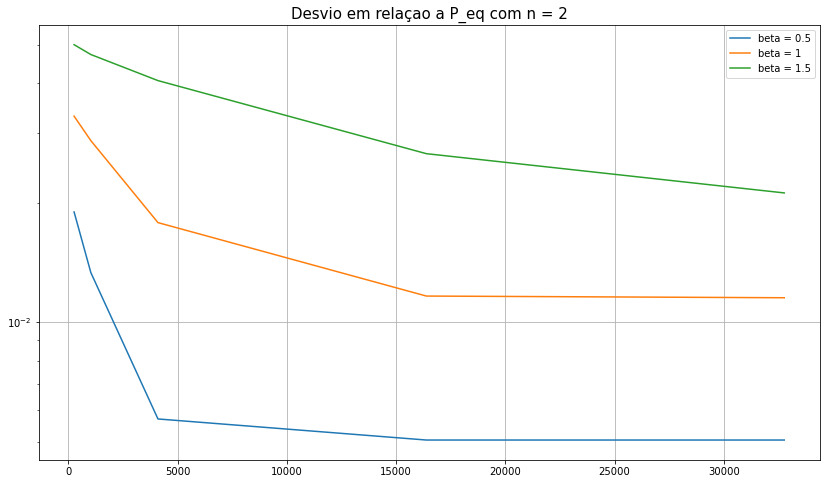

In [31]:
XX = np.arange(-5,5.1,0.1)
m_s = [8,10,12,14,15]
beta_s = [0.5,1,1.5]

P0 = np.zeros(len(XX))
P0[75] = 1   # o indice 75 corresponde à posição x = 2.5

lista_1 = [2**8,2**10,2**12,2**14,2**15]


plt.figure(figsize=(14,8))
for beta in beta_s:
    delta_P = []
    
    matriz = Markov(2,0.1,beta)  # n=2; delta = 0.1
    w,vr,vl = lin.eig(matriz,right=True,left=True) # w- autovalores; v - autovetores
    indices_ordenados = np.argsort(w)
    indice_w1 = indices_ordenados[-1]  # indice correspondente ao autovalor w = 1
    vr_w1 = vr[:,indice_w1]  # autovetor à direita com autovalor = 1 (autovalor máximo)
    vr_w1_norm = vr_w1/np.sum(vr_w1)   # normalizar o autovetor
    Peq = vr_w1_norm
    
    for m in m_s:
        P1 = P0
        for i in range((2**m)):
            P1 = P1@matriz

        delta_P.append(max(P1-Peq))
        
    declive,b = np.polyfit(lista_1,np.log(delta_P),deg=1)
    tau_exp = -1/declive
    print("Beta = {}".format(beta))
    print("Valor de tempo de relaxação experimental: {}".format(tau_exp))
    
    w,vr,vl = lin.eig(matriz,right=True,left=True)
    w_ordenado = np.sort(w)
    w_2 = w_ordenado[-2].real  # segundo autovalor mais elevado
    tau_esperado = -1/np.log(w_2)
    
    
    print("Tempo de relaxação teórico: {}".format(tau_esperado))
    erro = (abs(tau_esperado-tau_exp)/tau_esperado)*100
    print("Erro relativo associado ao tempo de termalização é= {}%".format(erro))
    print("############################################################################")
    
    
    plt.plot(lista_1,delta_P,label="beta = {}".format(beta))
    plt.legend()
    plt.title("Desvio em relaçao a P_eq com n = 2",fontsize = 15)
    plt.yscale("log")
    plt.grid()

#### 1.5 Spectral Decomposition and Equilibration Times

The evolution of $\mathbf{P}_0$ towards $\mathbf{P}_{\!\text{eq}}$ is described by the spectral decomposition:

$$
\mathbf{P}_t = \mathbf{M}^t\,\mathbf{P}_0 = \sum_\alpha \lambda_\alpha^t\,(\mathbf{l}_\alpha \cdot \mathbf{P}_0)\,\mathbf{r}_\alpha
$$

For large $t$, the only non-decaying mode is $\lambda_1 = 1$ (with $\mathbf{r}_1 = P_{\text{eq}}$). The deviation from stationarity is dominated by the **second eigenvalue** $\lambda_2$ (largest modulus among the rest):

$$
\Delta P_t \approx C\,|\lambda_2|^t \implies \tau_{\text{eq}} = \frac{-1}{\ln|\lambda_2|}
$$

**(a)** The times from 1.4(b) and 1.4(c) are shown to be consistent with this relation: $\tau_{\text{eq}}$ estimated by `polyfit` matches $-1/\ln|\lambda_2|$ computed directly from the spectrum.

From the spectral decomposition, the deviation at time $t$ is:

$$
\Delta P_t = \max_x \left| \sum_{\alpha \neq 1} \lambda_\alpha^t\,(\mathbf{l}_\alpha \cdot \mathbf{P}_0)\,\mathbf{r}_\alpha(x) \right|
\leq \sum_{\alpha \neq 1} |\lambda_\alpha|^t\,|\mathbf{l}_\alpha \cdot \mathbf{P}_0|\,\|\mathbf{r}_\alpha\|_\infty
$$

For sufficiently large $t$, the $\alpha = 2$ term (with $|\lambda_2|$ closest to 1) dominates all others, and the asymptotic behaviour is:

$$
\Delta P_t \sim |\lambda_2|^t = e^{t \ln|\lambda_2|} \implies \tau_{\text{eq}} = \frac{-1}{\ln|\lambda_2|}
$$

The $\tau_{\text{eq}}$ values obtained in 1.4(b) and 1.4(c) by linear fitting of $\ln(\Delta P_t)$ vs $t$ are consistent with this prediction.

In [8]:
# Responda Aqui

**(b)** Using the spectral formula $\tau_{\text{eq}} = -1/\ln|\lambda_2|$ computed directly from the spectrum of $\mathbf{M}$ (without simulation):

- $\tau_{\text{eq}}(\tilde{\beta})$ for $\tilde{\beta} \in [5 \times 10^{-3}, 2]$, with $n=1, 2$ and $\Delta = 0.01$.
- $\tau_{\text{eq}}(\Delta)$ for $\Delta \in [5 \times 10^{-4}, 10^2]$, with $n=1, 2$ and $\tilde{\beta} = 1.0$.

**$\tau_{\text{eq}}$ vs $\tilde{\beta}$:** approximately exponential growth with $\tilde{\beta}$ — **Arrhenius law**. The barrier height is $\propto 1/\Delta$, and the crossing rate scales as $e^{-\tilde{\beta}/\Delta}$, so $\tau_{\text{eq}} \propto e^{\tilde{\beta}/\Delta}$. For $n=2$, $\tau_{\text{eq}}$ is always lower than for $n=1$ (larger jumps facilitate crossing).

**$\tau_{\text{eq}}$ vs $\Delta$:**
- $\Delta \to 0$: $\tau_{\text{eq}} \to \infty$ because the barrier height diverges — the chain approaches an absorbing process.
- Large $\Delta$: $\tau_{\text{eq}}$ drops to a small plateau — no barrier to cross, equilibration is fast.
- For $n=2$ the transition to fast equilibration occurs at smaller $\Delta$ (size-2 jumps can bridge narrower barriers).

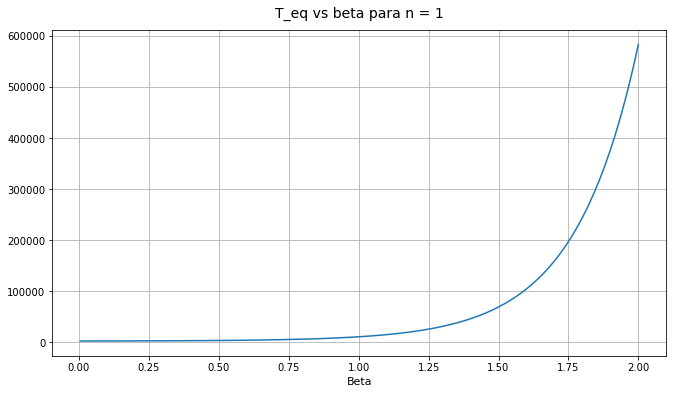

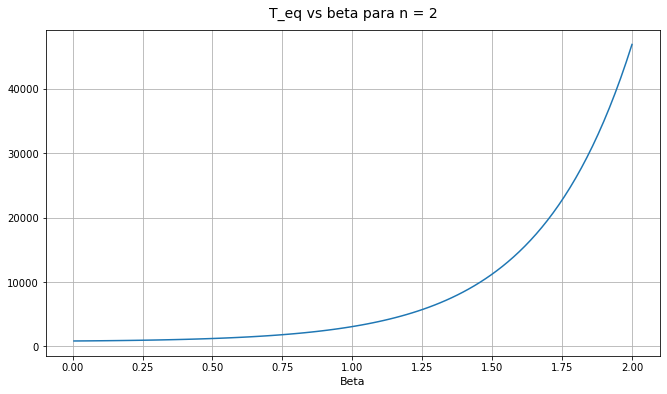

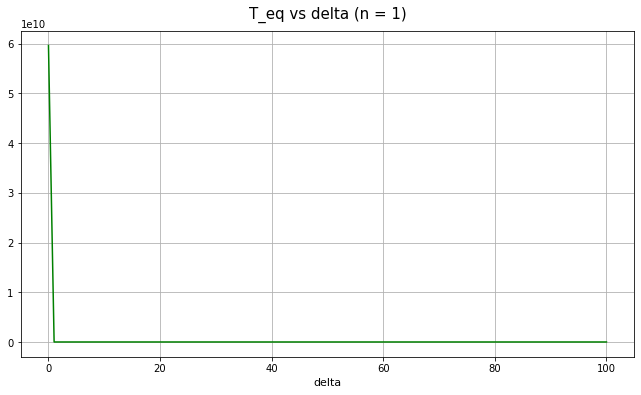

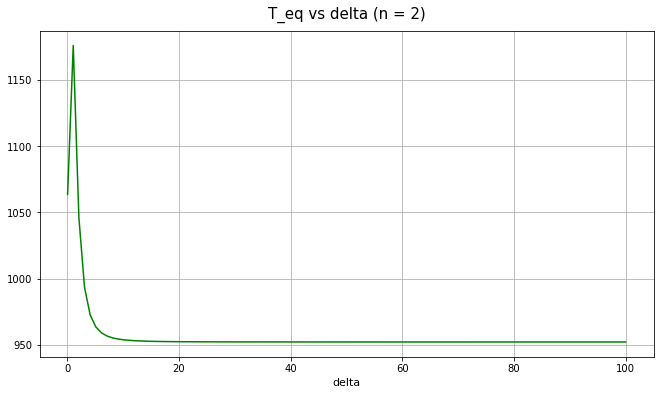

In [32]:
# T_eq em função de beta para n = 1 e n = 2; delta = 0.1

beta_s = np.linspace(0.005,2,100)
delta_s = np.linspace(0.02,100,100)
n_s = [1,2]

for n in n_s:
    tau_lista = []
    for beta in beta_s:
        matriz = Markov(n,0.1,beta) # delta = 0.1
        w,vr,vl = lin.eig(matriz,left=True,right=True)
        w_ordenados = np.sort(w)
        w_2 = w_ordenados[-2]  # 2ª autovalor mais elevado
        tau_teorico = -1/np.log(abs(w_2))
        tau_lista.append(tau_teorico)
        
    plt.figure(figsize=(11,6))
    plt.plot(beta_s,tau_lista)
    plt.title("T_eq vs beta para n = {}".format(n),fontsize=14,pad=12)
    plt.grid()
    plt.xlabel("Beta",fontsize=11)
    plt.show()
    
# Representação de T_eq para vários delta para n=1 e n = 2 e beta = 1.0
for n in n_s:
    tau_lista_1 = []
    
    for delta in delta_s:
        matriz = Markov(n,delta,1)
        w,vr,vl = lin.eig(matriz,right=True,left=True)
        w_ordenados = np.sort(w)
        w_2 = w_ordenados[-2]  # 2ª autovalor mais elevado
        tau_teorico = -1/np.log(abs(w_2))
        tau_lista_1.append(tau_teorico)
        
    plt.figure(figsize=(11,6))  
    plt.plot(delta_s,tau_lista_1,"g")
    plt.title("T_eq vs delta (n = {})".format(n),fontsize=15,pad=12)
    plt.xlabel("delta",fontsize=11)
    plt.grid()
    plt.show()

**(c)** Evolution of $\mathbf{P}'_{\!0} = (\delta_{x,2.5} + \delta_{x,-2.5})/2$ — an initial condition **already symmetric** across both wells — with $n=1$, $\tilde{\beta} = 0.1$ and $\Delta = 0.001$:

With $\Delta = 0.001$ the barrier is very tall and the two wells are nearly decoupled. The system has **two timescales**: a fast one (equilibration within each well) and a very slow one (redistribution of weight between wells). The symmetric initial condition eliminates the slow mode — no barrier crossing is needed and the distribution equilibrates quickly. The printed $\tau_{\text{eq}}$ (from $\lambda_2$) captures the inter-well timescale, but since $\mathbf{l}_2 \cdot \mathbf{P}'_0 \approx 0$ (the initial condition barely projects onto the slow mode), the observed decay is dominated by the third mode, which is much faster.

-2.500000000000009 2.4999999999999734
O tempo de termalização é= 529835250278881.3


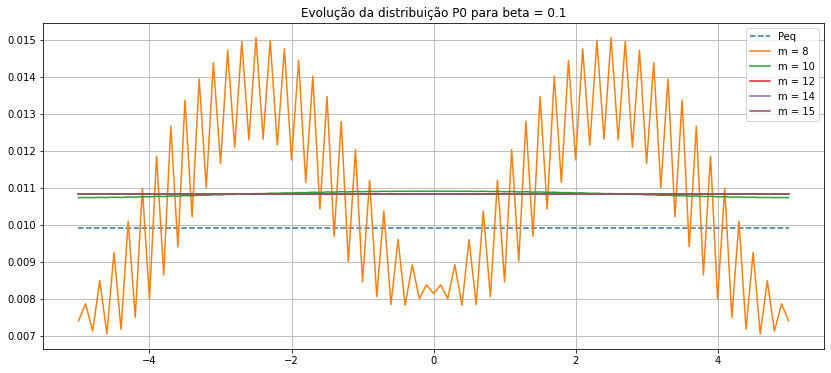

In [34]:
m_s = [8,10,12,14,15]    
XX = np.arange(-5,5.1,0.1)

P0 = np.zeros(len(XX))
P0[75] = 0.5  # na posição 75 x = 2.5
P0[25] = 0.5  # na posição 25 x = -2.5
print(XX[25],XX[75])

matriz = Markov(1,0.01,0.1) # n = 1; delta = 0.01 ; beta = 0.1
w,vr,vl = lin.eig(matriz,right=True,left=True)
indices_ordenados = np.argsort(w)
vr_1 = vr[:,indices_ordenados[-1]]  # autovetor à direita com autovalor = 1
vr_1_norm = vr_1/np.sum(vr_1)

w1 = w[indices_ordenados[-1]].real  # autovalor mais próximo de 1
tau = -1/np.log(w1)
Peq = vr_1_norm

plt.figure(figsize=(14,6))
plt.plot(XX,Peq,"--",label="Peq")
plt.title("Evolução da distribuição P0 para beta = {}".format(0.1))

for m in m_s:
    P1 = P0 # evitar alterar P0
    for i in range(2**m):
        P1 = P1@matriz

    plt.plot(XX,P1,label="m = {}".format(m))
    plt.legend()
    plt.grid()
print("O tempo de termalização é= {}".format(tau))

#### 1.6 Limit $\Delta \to 0^+$ — Near-Absorbing Chain

With $\Delta = 0.001$ (approaching the limit $\Delta \to 0^+$) the barrier is so narrow that for $n=1$ the jumps of length $\delta = 0.1$ never reach $x = 0$ from either side — the two wells become **completely decoupled**. The chain loses ergodicity.

The spectrum reveals **two eigenvalues $\approx 1$** (one per well), and the "stationary distribution" collapses onto a single well depending on the initial condition — meaning there are multiple local stationary distributions.

For $n=2$, size-$2\delta$ jumps can still cross the barrier, but extremely rarely — the chain is ergodic but with an astronomically large $\tau_{\text{eq}}$:

**For $n=1$, $\Delta = 0.001$:** $P_{\text{eq}}$ concentrates on a single well — the numerical eigensolver converges to one of the two near-degenerate stationary states. Two eigenvalues $\approx 1$ appear, revealing the near-reducibility of the chain. Classification: **nearly absorbing Markov process with two absorbing states** (one per well).

**For $n=2$, $\Delta = 0.001$:** both wells appear in $P_{\text{eq}}$ but the distribution may be numerically asymmetric — the chain is ergodic but with very large $\tau_{\text{eq}}$.

**In the true limit $\Delta \to 0^+$:** for $n=1$ the chain becomes **reducible** (two closed communicating classes, one per well, with no transitions between them). For $n=2$ the chain remains irreducible (ergodic) since size-$2\delta$ jumps can still cross the vanishing barrier, but the equilibration time diverges.

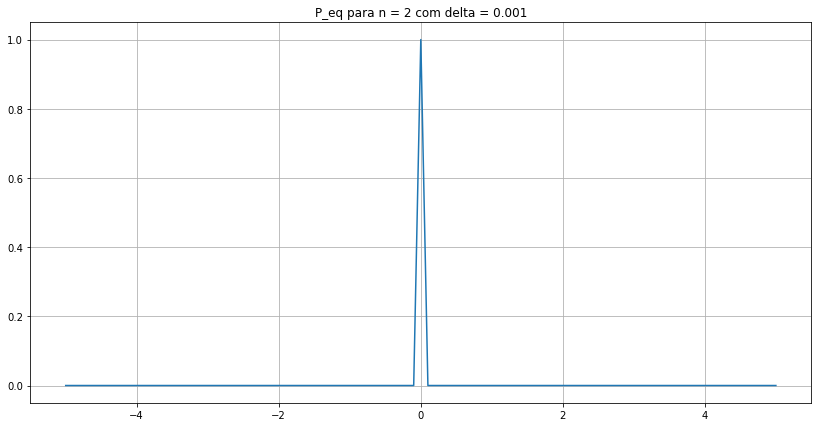

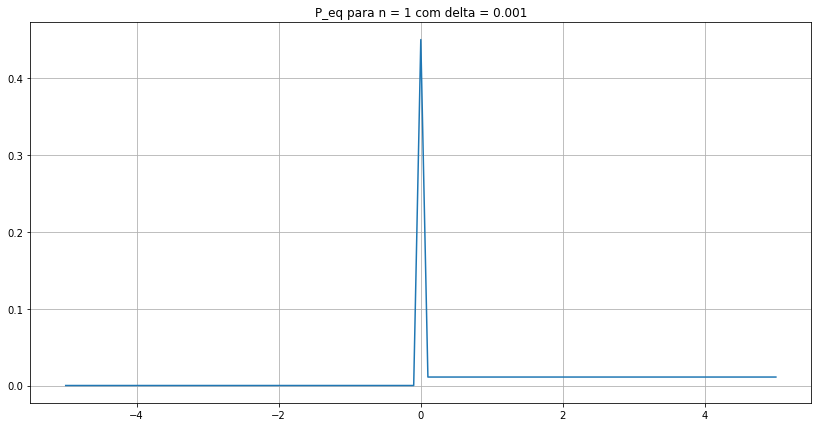

In [35]:
n_s = [1,2]
XX = np.arange(-5,5.1,0.1)

mat1 = Markov(n_s[0],0.001,1)
mat2 = Markov(n_s[1],0.001,1)


w1,vr1,vl1 = lin.eig(mat1,right=True,left=True)
w2,vr2,vl2 = lin.eig(mat2,right=True,left=True)

indices_ordenados1 = np.argsort(w1)
vr1_w1 = abs(vr1[:,indices_ordenados1[-1]]) # autovetor à direita com autovalor = 1 para n=1
vr1_w1_norm = vr1_w1/np.sum(vr1_w1)

indices_ordenados2 = np.argsort(w2)
vr2_w1 = abs(vr2[:,indices_ordenados2[-1]])  # autovetor à direita com autovalor
vr2_w1_norm = vr2_w1/np.sum(vr2_w1)


plt.figure(figsize=(14,7))
plt.plot(XX,vr2_w1_norm)
plt.title("P_eq para n = 2 com delta = {}".format(0.001))
plt.grid()
plt.show()    

plt.figure(figsize=(14,7))
plt.plot(XX,vr1_w1_norm)
plt.title("P_eq para n = 1 com delta = {}".format(0.001))
plt.grid()
plt.show()

#### 1.7 Metropolis Simulation — Direct Monte Carlo

Instead of repeatedly multiplying the matrix $\mathbf{M}$, the random walk is implemented directly: a routine that simulates the stochastic trajectory of a particle step by step.

At each step:
1. Propose a displacement $k\delta$ with $k \in \{-n,\ldots,-1,1,\ldots,n\}$ chosen uniformly.
2. Accept with probability $\min(1,\, e^{-\tilde{\beta}[V'(x')-V'(x)]})$.
3. If rejected, the particle stays at $x$.

Parameters: $n=1$, $\Delta=0.01$, $\tilde{\beta}=0.5$. The equivalence between this method and matrix evolution ($\mathbf{M}^t \mathbf{P}_0$) is demonstrated in the following sections.

The routine returns the sequence of visited positions. To simulate many independent trajectories, the function is called repeatedly with the same initial position $x_0$.

In [11]:
# Responda Aqui

**(a)** Starting from $x_0 = 2.5$, each trajectory evolves for $S = 2^9 = 512$ steps. This is repeated $2^{12} = 4096$ times. The **histogram of final positions** estimates the distribution $P_{2^9}(x)$ — the distribution after $2^9$ steps of the Markov chain.

The histogram of final positions of the $2^{12}$ independent trajectories is a sample estimate of $P_{2^9}(x)$. Comparing with the curve obtained by matrix evolution $\mathbf{M}^{2^9} P_0$ (next section) validates the Metropolis implementation.

In [12]:
# Responda Aqui

**(b)** Overlay of the Metropolis histogram (previous section) with the distribution evolved $S$ steps by the Markov matrix (computed in 1.4). Both methods should give equivalent results:

The agreement between the Monte Carlo histogram and the matrix evolution curve is excellent — confirming that the Metropolis routine correctly implements the Markov chain. Small differences are statistical fluctuations due to the finite number of samples ($2^{12}$).

In [13]:
# Responda Aqui

**(c)** A single trajectory of $S = 2^{23} \approx 8 \times 10^6$ steps, starting from $x_0 = 2.5$. The histogram of the **temporal series of positions** along the entire trajectory is compared with $P_{2^{23}}(x)$ obtained by matrix evolution.

The temporal histogram of a single long trajectory converges to $P_{\text{eq}}$, not to $P_{2^{23}}$ (which at this point is essentially $P_{\text{eq}}$ anyway). This illustrates the **ergodicity** of the chain: the time average along a sufficiently long trajectory is equivalent to the ensemble average over many independent trajectories.

In contrast with (a), where $2^{12}$ short trajectories ($2^9$ steps each) were used, here a single long trajectory is used. Both approaches converge to the same result because $S = 2^{23} \gg \tau_{\text{eq}}$ — the particle equilibrated long ago and the temporal histogram samples $P_{\text{eq}}$.

In [14]:
# Responda Aqui

---

### Part 2 — 2D Gas with Stochastic Elastic Collisions

A gas of $N$ particles of mass $m = 1$ is confined to a 2D square box $L \times L$. **Positions are irrelevant** — the model evolves only velocities, through two types of events per time step:

1. **Wall collision** (1% probability per step): a random particle has one randomly chosen velocity component negated — elastic reflection from a wall.
2. **Binary elastic collision** (99% probability per step): a randomly chosen pair $(i, j)$ undergoes a collision parametrised by $\phi$.

Time is measured in number of collision events.

#### 2.1 Conservation Laws and the Centre-of-Mass Frame

In an elastic collision between two particles with lab-frame velocities $\mathbf{v}_1$, $\mathbf{v}_2$, the **centre-of-mass (CM) velocity** is:

$$
\mathbf{v}_{\text{CM}} = \frac{\mathbf{v}_1 + \mathbf{v}_2}{2}
$$

In the **CM frame**, velocities are $\mathbf{u}_i = \mathbf{v}_i - \mathbf{v}_{\text{CM}}$:

$$
\mathbf{u}_1 = \frac{\mathbf{v}_1 - \mathbf{v}_2}{2}, \qquad \mathbf{u}_2 = -\mathbf{u}_1
$$

The total momentum in the CM frame is zero: $\mathbf{u}_1 + \mathbf{u}_2 = \mathbf{0}$. Energy conservation then requires:

$$
m\varepsilon = |\mathbf{p}_{1,f}|^2 \implies |\mathbf{u}_{1,f}| = |\mathbf{u}_{1,i}|
$$

The final momentum vector lies on a **circle** of radius $|\mathbf{u}_{1,i}|$. The collision **rotates** $\mathbf{u}_{1,i}$ by a random angle $\theta \sim \mathcal{U}([-\phi, \phi])$:

$$
\theta_f = \theta_i + \theta
$$

Final lab-frame velocities: $\mathbf{v}_{k,f} = \mathbf{u}_{k,f} + \mathbf{v}_{\text{CM}}$. Energy and momentum are conserved exactly by construction.

The parameter $\phi$ controls the interaction strength:

| $\phi$ | Meaning |
|---------|---------|
| $0$ | No deflection — particles pass through each other unchanged |
| small | Weak interaction — small random rotation, slow redistribution |
| $1.0$ | Moderate deflection |
| $\pi$ | Maximum randomisation — outgoing direction uniform in $[-\pi, \pi]$ |

#### 2.2 Collision Function

The function `EV(v1, v2, phi)` implements the following steps:

**(a)** Compute energy and linear momenta in the CM frame.

**(b)** Compute the angle of particle 1's momentum relative to $Ox$ in the CM frame.

**(c)** Add a random angle $\theta \sim \mathcal{U}([-\phi, \phi])$ to simulate the collision.

**(d)** Return the final velocities in the lab frame.

The CM velocity is $\mathbf{v}_{\text{CM}} = (\mathbf{v}_1 + \mathbf{v}_2)/2$.

The CM-frame velocities are $\mathbf{u}_i = \mathbf{v}_i - \mathbf{v}_{\text{CM}}$, so:

$$
\mathbf{u}_1 = \frac{\mathbf{v}_1 - \mathbf{v}_2}{2}, \qquad \mathbf{u}_2 = \frac{\mathbf{v}_2 - \mathbf{v}_1}{2} = -\mathbf{u}_1
$$

The CM-frame energy is $\varepsilon = |\mathbf{u}_1|^2$ (with $m=1$). The exit angle is obtained by adding the random $\theta$ to the entry angle, and the final lab-frame velocities are $\mathbf{v}_{k,f} = \mathbf{u}_{k,f} + \mathbf{v}_{\text{CM}}$.

**Verification:** total energy $|\mathbf{v}_{1,f}|^2 + |\mathbf{v}_{2,f}|^2 = |\mathbf{v}_{1,i}|^2 + |\mathbf{v}_{2,i}|^2$ and total momentum $\mathbf{v}_{1,f} + \mathbf{v}_{2,f} = \mathbf{v}_{1,i} + \mathbf{v}_{2,i}$ are conserved.

In [10]:
def EV(v1,v2,phi):
    v_cm = (v1+v2)/2  # velocidade do CM
    # velocidades no referencial do CM
    u1 = v1-v_cm
    u2 = v2-v_cm
    
    E1 = np.sum(u1**2)  # energia inicial no ref CM
    # print(E1)
    
    ang = np.arctan2(u1[1],u1[0])
    rand_ang = rd.random(1)*phi*2 - phi  # ângulo aleatório entre -phi e phi
    theta = ang + rand_ang
    
    u1_f = np.transpose(np.array([np.cos(theta),np.sin(theta)]))[0]*np.sqrt(E1)
    u2_f = - u1_f  # conservação do momento linear
    
    E2 = np.sum(u1_f**2)  # energia final no referencial CM
    # print(E2)
    
    v1_f = u1_f + v_cm
    v2_f = u2_f + v_cm
    
    return (v1_f,v2_f)

# Exemplo
v_ex = np.array([1,2])
v_ex_1 = np.array([-1,-4])
a = EV(v_ex,v_ex_1,0.1)
a[0]+a[1]  # verifica-se a conservação da velocidade do CM
# A energia também se está a conservar (fazer os prints para confirmar)

array([ 0., -2.])

#### 2.3 Random Velocity Initialisation with Fixed Total Energy

The function `v_aleatorio(N, E)` returns an $(N, 2)$ array of random velocities with total energy exactly equal to $E$. The method uses the **Dirichlet distribution** to generate $N$ random energies summing to $E$, then assigns each particle a random direction and the corresponding speed.

The total energy is $E = \sum_{i=1}^N \frac{1}{2}(v_{ix}^2 + v_{iy}^2)$.

Individual energies are generated with `np.random.dirichlet(np.ones(N)) * E`, which guarantees $\sum_i E_i = E$ with a uniform distribution over the simplex. Each energy $E_i$ corresponds to a speed $|\mathbf{v}_i| = \sqrt{2E_i}$ with a random uniform direction.

In [3]:
def v_aleatorio(N,E):
    v_final_1 = []
    E_aleatorias = np.random.dirichlet(np.ones(N))*E  # array de energias aleatórias cuja soma dá E de tamanho N
    v_aleatorias = np.sqrt(2*E_aleatorias) # array do módulo das velocidades
    
    for v_aleatoria in v_aleatorias:
        # escolher de forma aleatória as componentes das velocidades
        v_square = np.random.dirichlet(np.ones(2))*(v_aleatoria**2)
        v = np.sqrt(v_square)
        num_x = random.randint(0,1)
        num_y = random.randint(0,1)
        if num_x == 1:    # colide com parede vertical; muda só a componente segundo x
            v[0] *= -1
        elif num_y == 1:   # colide com parede horizontal ; muda só a componente y
            v[1] *= -1
            
        v_final_1.append(v)
    
    v_final = np.array(v_final_1)
        
    return (v_final)

# Exemplo
XC = v_aleatorio(5,10)  # 5 partículas com energia E = 10
print(XC)
print(np.sum(XC**2/2))  # energia dá bem

[[ 1.63660105 -0.93580371]
 [-1.98519704  1.55466781]
 [-2.0457187   1.0694819 ]
 [-0.49071815  1.01369546]
 [ 0.7475291   1.71227044]]
10.0


#### 2.4 Collision Dynamics and Velocity Time Series

The function `dinamica(N, E, phi, colisoes)` simulates the gas evolution. At each step:
- With 1% probability: wall collision (random inversion of one velocity component of a random particle).
- With 99% probability: elastic collision between a random pair $(i, j)$ via `EV`.

For $N=30$, $E=10$, $\phi=0.1$, over $10^4$ collisions, $v_x^{(i)}$ vs time is plotted for all particles:

Flat segments: the particle was not involved in any collision. **Sharp vertical jumps**: wall collision events — one velocity component is negated instantaneously. **Gradual changes**: inter-particle collisions with small $\phi = 0.1$ — the momentum rotation is small per event, so velocity changes gradually.

Wall collisions with vertical walls invert $v_x$ (visible as sign reversals), while collisions with horizontal walls invert $v_y$ and leave $v_x$ unchanged.

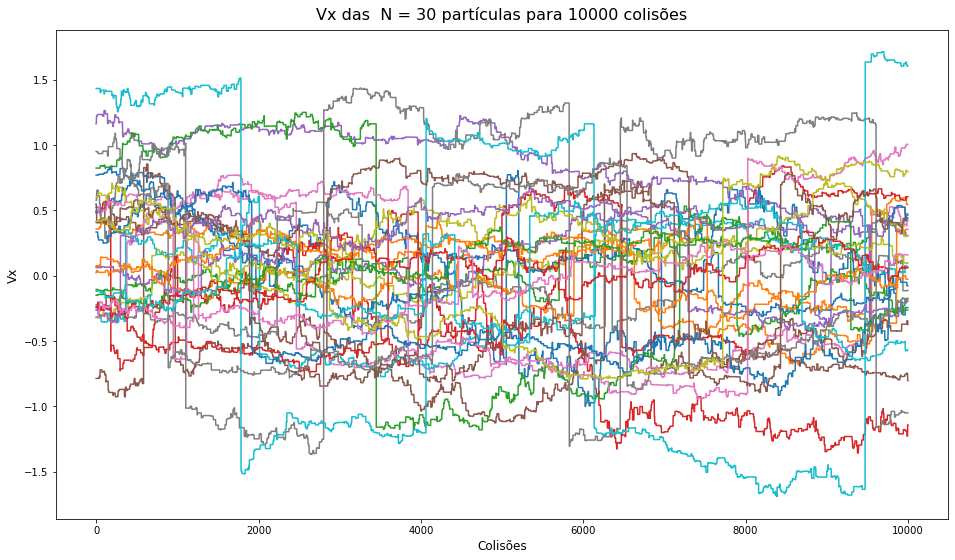

In [4]:
def dinamica(N,E,phi,colisoes):
    # a coluna y de cada array contém as velocidades de todas as N partículas após a colisão nº y
    res_vx = np.zeros([N,colisoes],float)  # cada linha irá conter as velocidades vx de uma só partícula
    res_vy = np.zeros([N,colisoes],float)  # cada linha irá conter as velocidades vy de uma só partícula
    v_particulas = v_aleatorio(N,E)  # array com velocidades iniciais das partículas (aleatórias)
    # este array irá ser atualizado ao longo desta função pelo que a cada colisão contém as velocidades atualizadas
    
    for i in range(N):
        # inicializar os arrays com as velocidades inicias
        res_vx[i,:] = v_particulas[:,0][i]
        res_vy[i,:] = v_particulas[:,1][i]
        
    colisoes_parede = 0 # variavel que irá conter o nº de colisões com as paredes
    
    for j in range(colisoes):
        num = random.randint(1,100)  # a probabilidade de sair 1 é aproximadamente 0.01, ou seja 1%
        
        if num == 1: # colisão de uma particula com a parede
            colisoes_parede += 1
            indice_parede = random.randint(0,N-1)
            v_parede = v_particulas[indice_parede]
            num_parede = random.randint(0,1)
            if num_parede == 0:
                res_vx[indice_parede,j:] = -v_parede[0]  # colide com parede vertical
            else:
                res_vy[indice_parede,j:] = -v_parede[1] # colide com parede horizontal
                
            v_particulas[indice_parede] = -v_parede # atualizar as velocidades das partículas
            
        else:
            # considerando uma colisão entre um par de partículas
            # escolha aleatória de duas partículas que colidem de forma elástica
            indice_1 = random.randint(0,N-1)
            indice_2 = random.randint(0,N-1)
            v1 = v_particulas[indice_1]
            v2 = v_particulas[indice_2]
            # determinação da velocidade das duas partículas após colisão
            v1_f,v2_f = EV(v1,v2,phi)
            res_vx[indice_1,j:] = v1_f[0]
            res_vx[indice_2,j:] = v2_f[0]
            res_vy[indice_1,j:] = v1_f[1]
            res_vy[indice_2,j:] = v2_f[1]
            # atualizar as velocidades das partículas
            v_particulas[indice_1] = v1_f
            v_particulas[indice_2] = v2_f
            
    # print("Número de colisões com a parede: {}".format(colisoes_parede))
    
    return (res_vx,res_vy)


v_ox,v_oy = dinamica(30,10,0.1,10**4)

plt.figure(figsize=(16,9))        
for N_particula in range(0,30): 
    plt.plot(v_ox[N_particula,:])

plt.title("Vx das  N = 30 partículas para {} colisões".format(10**4),fontsize=16,pad=10)
plt.ylabel("Vx",fontsize=12)
plt.xlabel("Colisões",fontsize=12)
plt.show()

#### 2.5 Velocity Histogram at Equilibrium

After $10^5$ collisions, the histogram of $v_x$ of particle 1 estimates the equilibrium velocity distribution. For an ideal 2D gas at temperature $k_BT = E/N$, the Maxwell-Boltzmann distribution predicts:

$$
f(v_x) = \frac{1}{\sqrt{2\pi k_BT}}\,e^{-v_x^2/(2k_BT)}, \qquad k_BT = \frac{E}{N} = \frac{10}{30} = \frac{1}{3}
$$

The histogram should be a Gaussian centred at 0 with $\sigma = \sqrt{E/N} \approx 0.58$:

The histogram is approximately Gaussian, centred at zero with $\sigma \approx 0.58$ — consistent with the Maxwell-Boltzmann distribution at equilibrium temperature $k_BT = E/N = 1/3$.

For $\phi = 0.1$ (weak interaction) thermalisation is slow, so $10^5$ collisions may not be fully sufficient — the histogram may still differ slightly from the theoretical Gaussian, particularly in the tails.

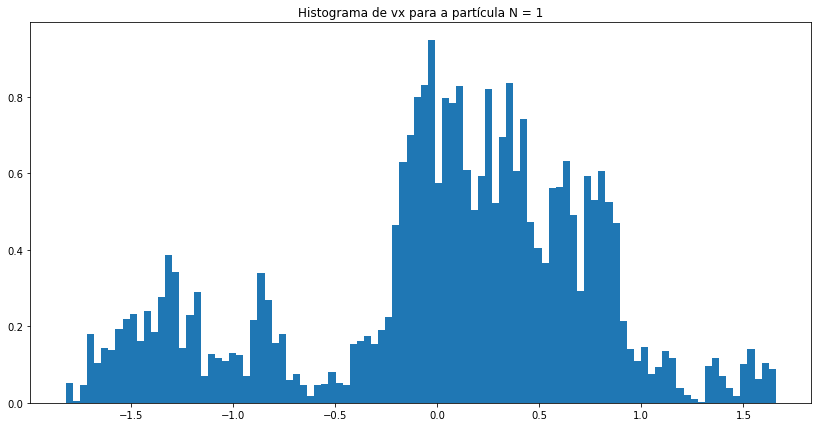

In [37]:
v_ox,v_oy = dinamica(30,10,0.1,10**5)

plt.figure(figsize=(14,7))
plt.hist(v_ox[0,:],density=True,bins=100)
plt.title("Histograma de vx para a partícula N = 1")
plt.show()

#### 2.6 Approach to Equilibrium — Microcanonical Ensemble

To study how the distribution converges to Maxwell-Boltzmann, 300 independent initialisations are run (all with $E=10$, $N=30$, $\phi=1.0$) and histograms of all particle velocities are computed every 10 collisions up to $t = 50$.

The theoretical equilibrium distribution (2D Maxwell-Boltzmann) is:

$$
f(v_x) = \frac{1}{\sqrt{\pi}}\,e^{-v_x^2} \qquad \text{(in normalised units with } k_BT = 1/3\text{)}
$$

The experimental distributions approach the Gaussian as $t$ grows. For $\phi = 1.0$ convergence is rapid — by $t = 50$ collisions the histograms are visually indistinguishable from the theoretical Gaussian.

A **dip near $v_x = 0$** is visible at small $t$: this is an artefact of the initialisation via `v_aleatorio`, which generates velocities with non-zero energies (speed is never exactly zero). This dip fills in as collisions redistribute momenta and the system thermalises.

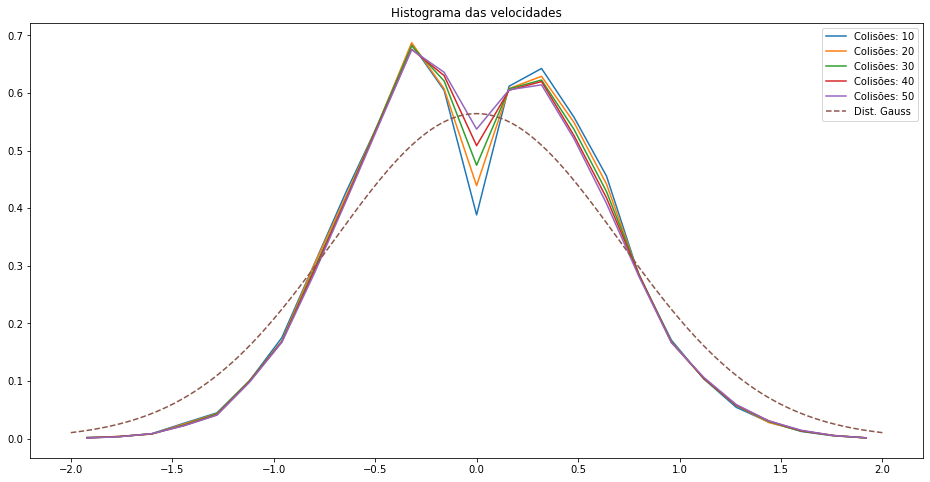

In [5]:
def Histograma(Amostra,a,b,bins):
    Amostra1 = 1.0*Amostra[(Amostra>a) & (Amostra<b)]
    XX = np.linspace(a,b,bins+1); XX = (XX[1:] + XX[:-1])*0.5
    Hist = np.zeros(len(XX))
    Indices = (bins*(Amostra1 - a)/(b-a)).astype(np.int32)
    for i in Indices:
        Hist[i] += 1
    Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade
    return XX, Hist

def Gaussiana(v):  # Gaussiana normalizada (integral dá um)
    c = 1/np.sqrt(np.pi)
    return c* np.exp(-v**2)

lista_10 = []
lista_20 = []
lista_30 = []
lista_40 = []
lista_50 = []

for j in range(300):
    velocidades_aleatorias = v_aleatorio(30,10)  # N=30 ; E=10
    v_ox,v_oy = dinamica(30,10,1.0,50)  #phi = 1.0 ; 50 colisões
    lista_10.append(v_ox[0:,:10].flatten().tolist())
    lista_20.append(v_ox[0:,:20].flatten().tolist())
    lista_30.append(v_ox[0:,:30].flatten().tolist())
    lista_40.append(v_ox[0:,:40].flatten().tolist())
    lista_50.append(v_ox[0:,:50].flatten().tolist())
    
listas = [lista_10,lista_20,lista_30,lista_40,lista_50]

plt.figure(figsize=(16,8))
n = 10         
for lista in listas:
    array = np.array(lista)
    xx,yy = Histograma(array,-2,2,25)
    plt.plot(xx,yy,label="Colisões: {}".format(n))
    n += 10
    # plt.hist(lista,density=True,bins=10)
    
plt.plot(np.linspace(-2,2,1000),Gaussiana(np.linspace(-2,2,1000)),"--",label="Dist. Gauss")
plt.title("Histograma das velocidades")
plt.legend()
plt.show()

#### 2.7 Effect of Interaction Strength $\phi$

The same analysis is repeated for $\phi \in \{0,\,0.1,\,1.0,\,\pi\}$ at times $t \in \{0,\,40,\,80,\,160,\,200\}$. The parameter $\phi$ controls how much each collision randomises the momentum — larger $\phi$ means more information erased per event:

| $\phi$ | Observed behaviour |
|--------|-------------------|
| $0$ | Distribution **does not evolve** — zero-degree rotation leaves velocities unchanged. No thermalisation without interaction. |
| $0.1$ | **Slow** convergence — even at $t=200$ the distribution has not fully reached the Gaussian. The dip near $v_x=0$ persists. |
| $1.0$ | **Moderate** convergence — visually Gaussian by $t \approx 80$. |
| $\pi$ | **Very fast** convergence — already Gaussian at $t=40$. Each collision fully randomises the relative momentum direction. |

Larger $\phi$ $\Rightarrow$ more randomisation per collision $\Rightarrow$ faster loss of information about the initial state $\Rightarrow$ faster thermalisation.

<ipython-input-5-0becd52dab54>:8: RuntimeWarning: divide by zero encountered in double_scalars
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade
<ipython-input-5-0becd52dab54>:8: RuntimeWarning: invalid value encountered in multiply
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade


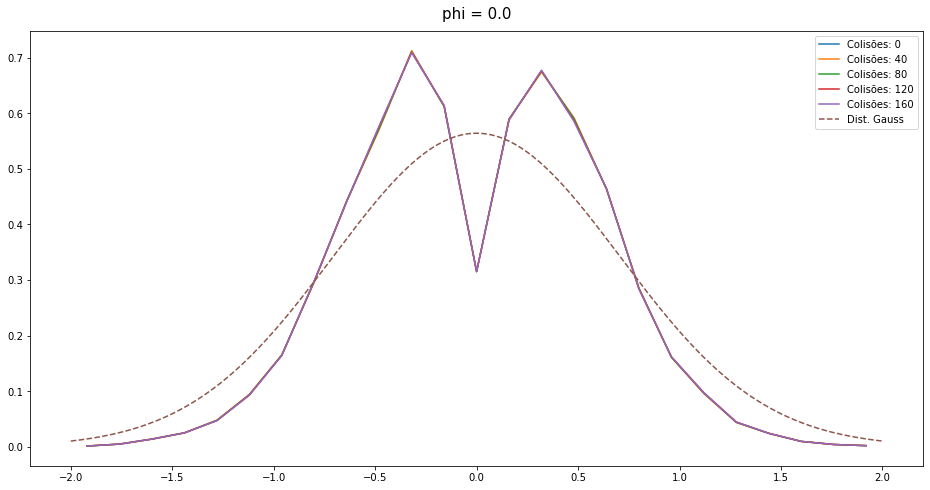

<ipython-input-5-0becd52dab54>:8: RuntimeWarning: divide by zero encountered in double_scalars
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade
<ipython-input-5-0becd52dab54>:8: RuntimeWarning: invalid value encountered in multiply
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade


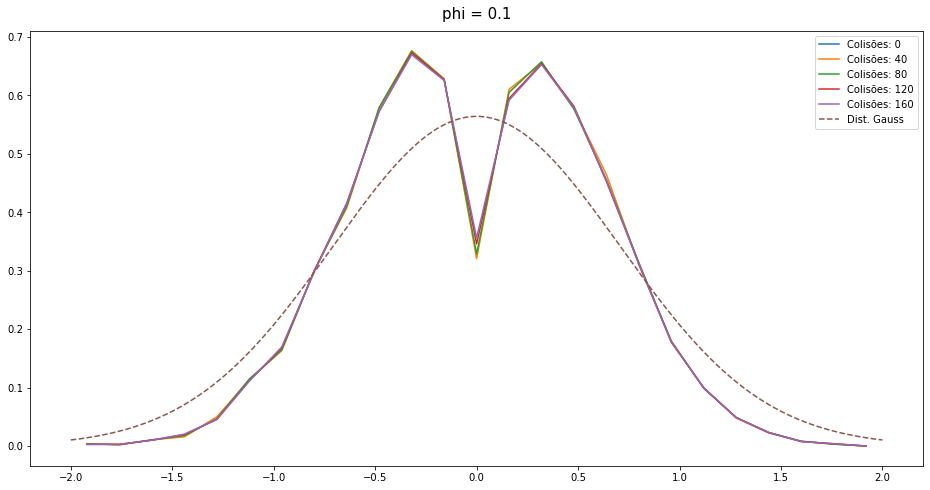

<ipython-input-5-0becd52dab54>:8: RuntimeWarning: divide by zero encountered in double_scalars
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade
<ipython-input-5-0becd52dab54>:8: RuntimeWarning: invalid value encountered in multiply
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade


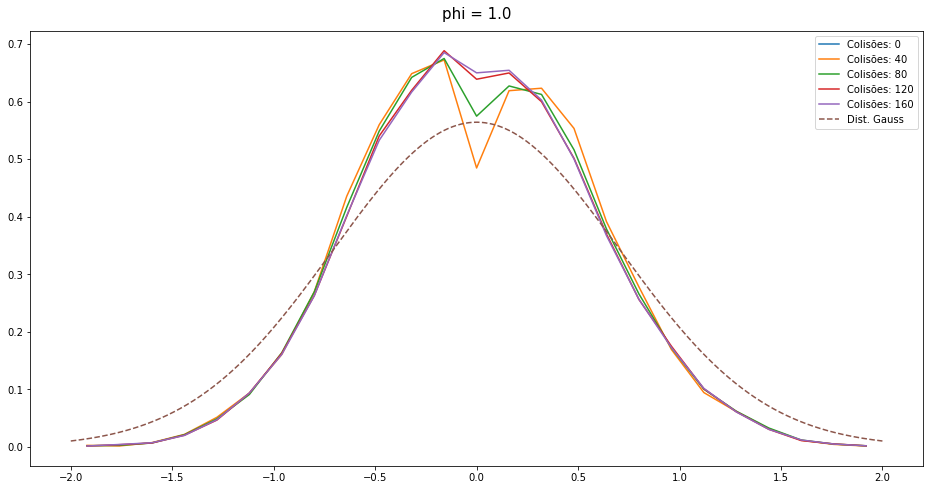

<ipython-input-5-0becd52dab54>:8: RuntimeWarning: divide by zero encountered in double_scalars
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade
<ipython-input-5-0becd52dab54>:8: RuntimeWarning: invalid value encountered in multiply
  Hist *= 1/np.sum(Hist)/(XX[1]-XX[0]) # Normalização em Densidade


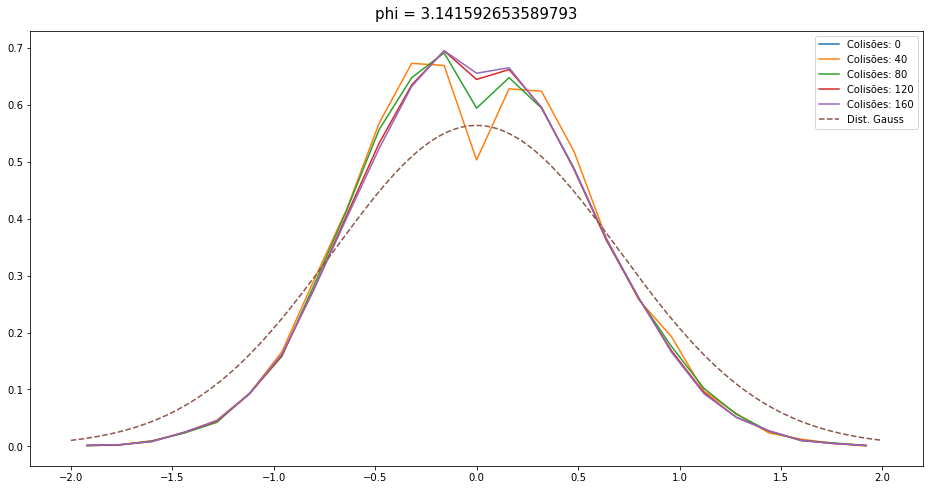

In [6]:
phi_s = [0.0,0.1,1.0,np.pi]
tempos = [0,40,80,160,200]

for phi in phi_s:

    lista_0 = []
    lista_40 = []
    lista_80 = []
    lista_160 = []
    lista_200 = []

    for j in range(300):
        velocidades_aleatorias = v_aleatorio(30,10)  # N=30 ; E=10
        v_ox,v_oy = dinamica(30,10,phi,200)  # 200 colisões
        lista_0.append(v_ox[0:,:0].flatten().tolist())
        lista_40.append(v_ox[0:,:40].flatten().tolist())
        lista_80.append(v_ox[0:,:80].flatten().tolist())
        lista_160.append(v_ox[0:,:160].flatten().tolist())
        lista_200.append(v_ox[0:,:200].flatten().tolist())

    listas = [lista_0,lista_40,lista_80,lista_160,lista_200]

    plt.figure(figsize=(16,8))
    n = 0        
    for lista in listas:
        array = np.array(lista)
        xx,yy = Histograma(array,-2,2,25)
        plt.plot(xx,yy,label="Colisões: {}".format(n))
        n += 40
        # plt.hist(lista,density=True,bins=10)

    plt.plot(np.linspace(-2,2,1000),Gaussiana(np.linspace(-2,2,1000)),"--",label="Dist. Gauss")
    plt.title("phi = {}".format(phi),fontsize=15,pad=12)
    plt.legend()
    plt.show()

#### 2.8 Single-Particle Energy Distribution and the Boltzmann Law

To analyse the effect of system size, the energy distribution of particle 1 is studied for $N \in \{3,\,5,\,11,\,17\}$ with $E=10$ and $\phi=1.0$.

In the **microcanonical ensemble** with $N$ particles and total energy $E$, the exact distribution of a single particle's energy $\varepsilon_1$ is:

$$
P(\varepsilon_1) \propto \left(1 - \frac{\varepsilon_1}{E}\right)^{N-2} \xrightarrow{N \to \infty} e^{-\varepsilon_1 N/E} = e^{-\varepsilon_1/k_BT}
$$

This is the fundamental statistical mechanics result for the **emergence of the canonical ensemble from the microcanonical one**: when $N$ is large, the remaining $N-1$ particles act as a thermal reservoir for particle 1, and its energy distribution converges to the Boltzmann exponential $e^{-\varepsilon/k_BT}$.

For $N=3$: the distribution is broad and clearly non-exponential — finite-size effects dominate. With only 3 particles the energy available to particle 1 can vary widely.

For $N=5$: an exponential tail begins to emerge.

For $N=11, 17$: histograms are well approximated by $P(\varepsilon) \propto e^{-\varepsilon N/E}$, converging to the Boltzmann distribution. The decay is steeper (smaller mean energy $\langle \varepsilon_1 \rangle = E/N$) as $N$ grows — the same total energy is distributed among more particles, making each one "colder".

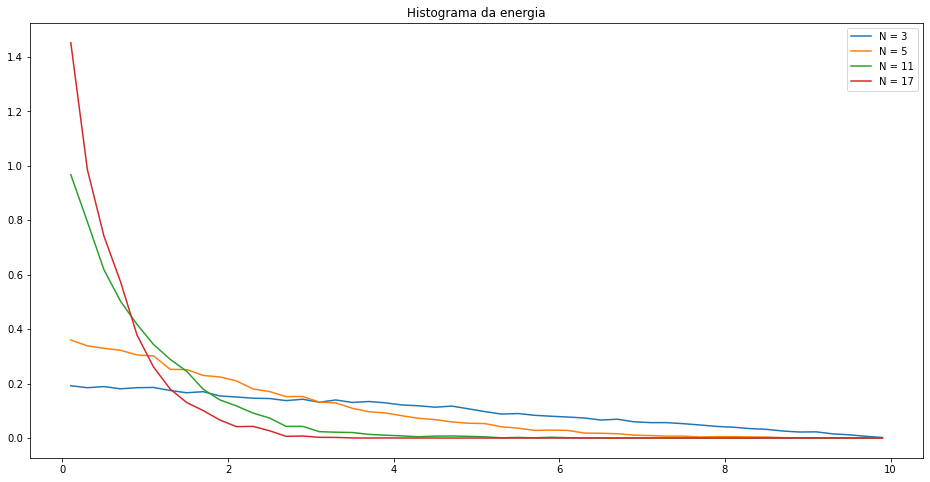

In [12]:
N_s = [3,5,11,17]

plt.figure(figsize=(16,8))
for N1 in N_s:
    v_ox,v_oy = dinamica(N1,10,1.0,10**5) # phi = 1.0; Etotal = 10
    v1_x = v_ox[0,:]
    v1_y = v_oy[0,:]
    E1 = 0.5*(v1_x**2 + v1_y**2)
    
    xx,yy = Histograma(E1,0,10,50)
    plt.plot(xx,yy,label="N = {}".format(N1))
    plt.title("Histograma da energia")
    plt.legend()
    
plt.show()